Load Necessary Packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem import SnowballStemmer

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, precision_score, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import re, warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier

SEED = 42
np.random.seed(SEED)

In [2]:
LIKERT_ORDER = ["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"]
PALETTE = {"Strongly disagree": "#d9534f", "Disagree": "#f0ad4e",
           "Neutral": "#aaaaaa", "Agree": "#5bc0de", "Strongly agree": "#3a8fc2"}

In [3]:
# Qualtrics exports 3 header rows; row 0 = col names, rows 1-2 = metadata
df = pd.read_csv("data.csv", skiprows=[1, 2])
 
# Convert duration to numeric and minutes
df["Duration (in seconds)"] = pd.to_numeric(df["Duration (in seconds)"], errors="coerce")
df["duration_min"] = df["Duration (in seconds)"] / 60
 
# Normalise free-text major field (basic grouping)
def normalise_major(m):
    m = str(m).lower().strip()
    if "stat" in m and "data" in m:  return "Stats & Data Science"
    if "stat" in m:                  return "Stats & Data Science"
    if "computer" in m or "cs" == m: return "Computer Science"
    if "business" in m or "econ" in m: return "Business/Econ"
    if "bio" in m or "mcdb" in m or "physio" in m: return "Life Sciences"
    if "psych" in m:                 return "Psychology"
    if "comm" in m:                  return "Communication"
    if "math" in m:                  return "Math"
    if "mech" in m or "engineer" in m: return "Engineering"
    return "Other"
 
df["major_group"] = df["major"].apply(normalise_major)
 
# Likert cols
SM_LIKERT = ["interaction", "comparison", "lose_track", "consume", "drained",
             "comment_msg", "relationships", "create", "connected",
             "anxious", "lonely", "down", "unable_relax"]
 
AI_LIKERT = ["ai_stressed", "ai_post_social", "ai_less_lonely",
             "ai_judgmental", "ai_mood_imp"]
 
SM_LABELS = {
    "interaction":  "Scroll without interacting",
    "comparison":   "Compare life to others",
    "lose_track":   "Lose track of time",
    "consume":      "Mainly consume content",
    "drained":      "Feel mentally drained",
    "comment_msg":  "Frequently comment/message",
    "relationships":"Use for meaningful relationships",
    "create":       "Actively post/create",
    "connected":    "Feel socially connected",
    "anxious":      "Feel anxious after scrolling",
    "lonely":       "Feel lonely after scrolling",
    "down":         "Feel down/unmotivated",
    "unable_relax": "Difficulty relaxing after SM",
}
 
AI_LABELS = {
    "ai_stressed":    "Use AI when stressed",
    "ai_post_social": "Use AI after negative SM exp.",
    "ai_less_lonely": "AI helps feel less lonely",
    "ai_judgmental":  "AI feels less judgmental",
    "ai_mood_imp":    "AI improves my mood",
}
 
for col in SM_LIKERT + AI_LIKERT:
    df[col] = pd.Categorical(df[col], categories=LIKERT_ORDER, ordered=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "savefig.facecolor": "none",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "grid.linewidth": 0.8,
    "font.family": "DejaVu Sans",   # change to "Arial" if available on your system
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelcolor": "#444444",
    "xtick.color": "#666666",
    "ytick.color": "#666666",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "text.color": "#222222",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

In [4]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows (respondents) : {len(df)}")
print(f"Columns            : {df.shape[1]}")
print(f"\nMissing values per survey column:")
survey_cols = ["gender","grade","major_group","time","ai_usage"] + SM_LIKERT + AI_LIKERT
print(df[survey_cols].isnull().sum().to_string())
 
print(f"\nSurvey duration (minutes):")
print(df["duration_min"].describe().round(1).to_string())
outliers = df[df["duration_min"] > 30]
print(f"\nDuration outliers (>30 min): {len(outliers)} respondents — likely left browser open")

DATASET OVERVIEW
Rows (respondents) : 94
Columns            : 48

Missing values per survey column:
gender            0
grade             0
major_group       0
time              0
ai_usage          0
interaction       0
comparison        0
lose_track        0
consume           0
drained           0
comment_msg       0
relationships     0
create            0
connected         0
anxious           0
lonely            0
down              0
unable_relax      0
ai_stressed       0
ai_post_social    0
ai_less_lonely    0
ai_judgmental     0
ai_mood_imp       0

Survey duration (minutes):
count      94.0
mean       43.5
std       264.0
min         1.4
25%         2.7
50%         3.7
75%         5.3
max      1903.4

Duration outliers (>30 min): 3 respondents — likely left browser open


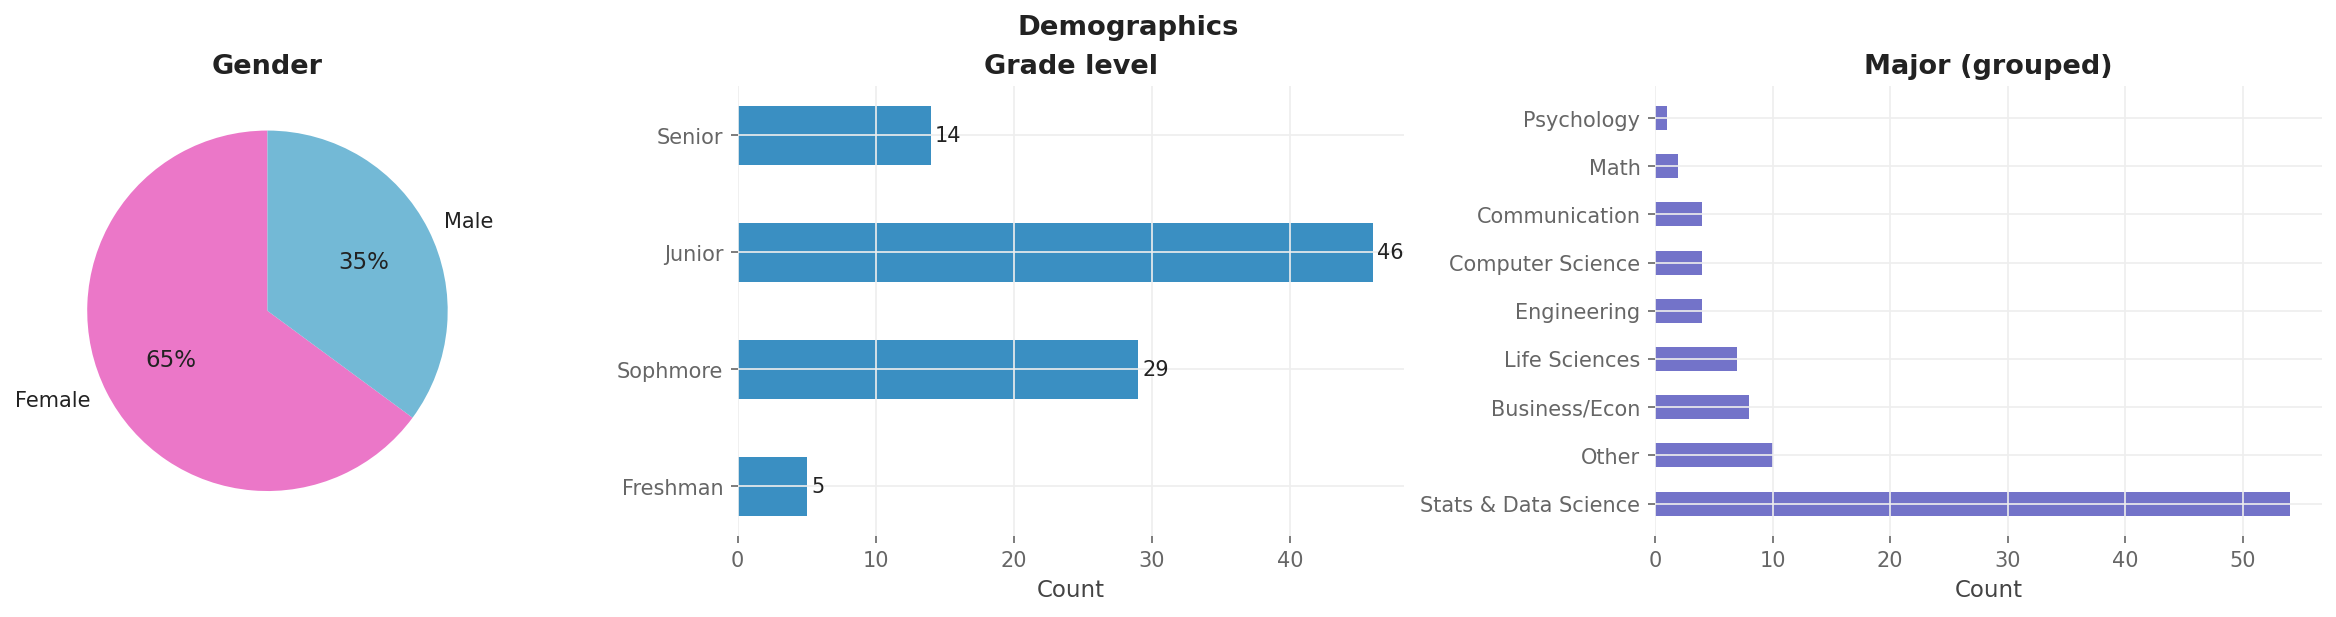

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle("Demographics", fontweight="bold")
 
# Gender
g_counts = df["gender"].value_counts()
axes[0].pie(g_counts, labels=g_counts.index, autopct="%1.0f%%",
            colors=["#eb77c8", "#73b9d6"], startangle=90,
            wedgeprops={"linewidth": 0})
axes[0].set_title("Gender")
 
# Grade
gr_order = ["Freshman", "Sophmore", "Junior", "Senior"]
gr_counts = df["grade"].value_counts().reindex(gr_order).fillna(0)
axes[1].barh(gr_counts.index, gr_counts.values, color="#3a8fc2", height=0.5)
axes[1].set_xlabel("Count")
axes[1].set_title("Grade level")
for i, v in enumerate(gr_counts.values):
    axes[1].text(v + 0.3, i, str(int(v)), va="center", fontsize=10)
 
# Major (grouped)
maj_counts = df["major_group"].value_counts()
axes[2].barh(maj_counts.index, maj_counts.values, color="#7373c9", height=0.5)
axes[2].set_xlabel("Count")
axes[2].set_title("Major (grouped)")

plt.show()

EDA

Text(0.5, 1.0, 'Daily time on social media')

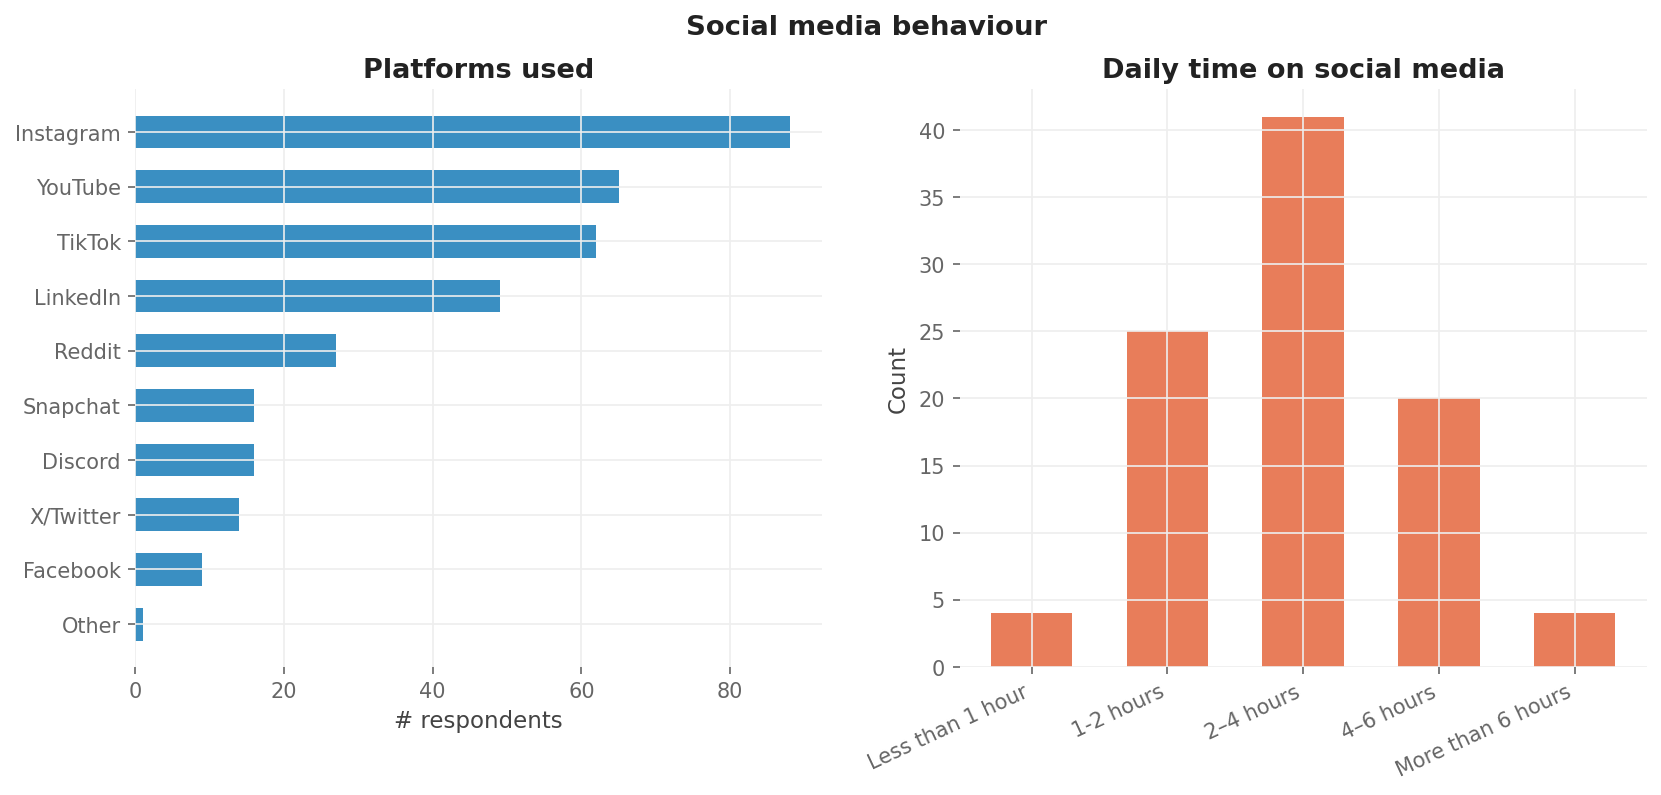

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Social media behaviour", fontweight="bold")
 
# Platforms (multi-select — explode comma-separated)
platforms = (df["socialmedia_platform"].str.split(",")
               .explode().str.strip().value_counts())
axes[0].barh(platforms.index[::-1], platforms.values[::-1], color="#3a8fc2", height=0.6)
axes[0].set_xlabel("# respondents")
axes[0].set_title("Platforms used")
 
# Daily time
time_order = ["Less than 1 hour", "1-2 hours", "2–4 hours", "4–6 hours", "More than 6 hours"]
t_counts = df["time"].value_counts().reindex(time_order).fillna(0)
axes[1].bar(range(len(t_counts)), t_counts.values, color="#e87d5a", width=0.6)
axes[1].set_xticks(range(len(t_counts)))
axes[1].set_xticklabels(time_order, rotation=25, ha="right")
axes[1].set_ylabel("Count")
axes[1].set_title("Daily time on social media")

helper

In [7]:
import matplotlib.ticker as mticker

def stacked_likert(ax, col_map, title):
    """Simple 100% stacked horizontal bar — one segment per response category."""
    rows = list(col_map.keys())
    labels = [col_map[r] for r in rows]
    n = len(df)
 
    lefts = np.zeros(len(rows))
    for cat in LIKERT_ORDER:
        vals = np.array([df[r].value_counts().get(cat, 0) / n * 100 for r in rows])
        bars = ax.barh(labels, vals, left=lefts, color=PALETTE[cat], label=cat, height=0.55)
        # Label segments that are wide enough to read
        for bar, v in zip(bars, vals):
            if v >= 8:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        f"{v:.0f}%", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
        lefts += vals
 
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))
    ax.set_xlabel("% of respondents")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8, ncol=2, framealpha=0.7)

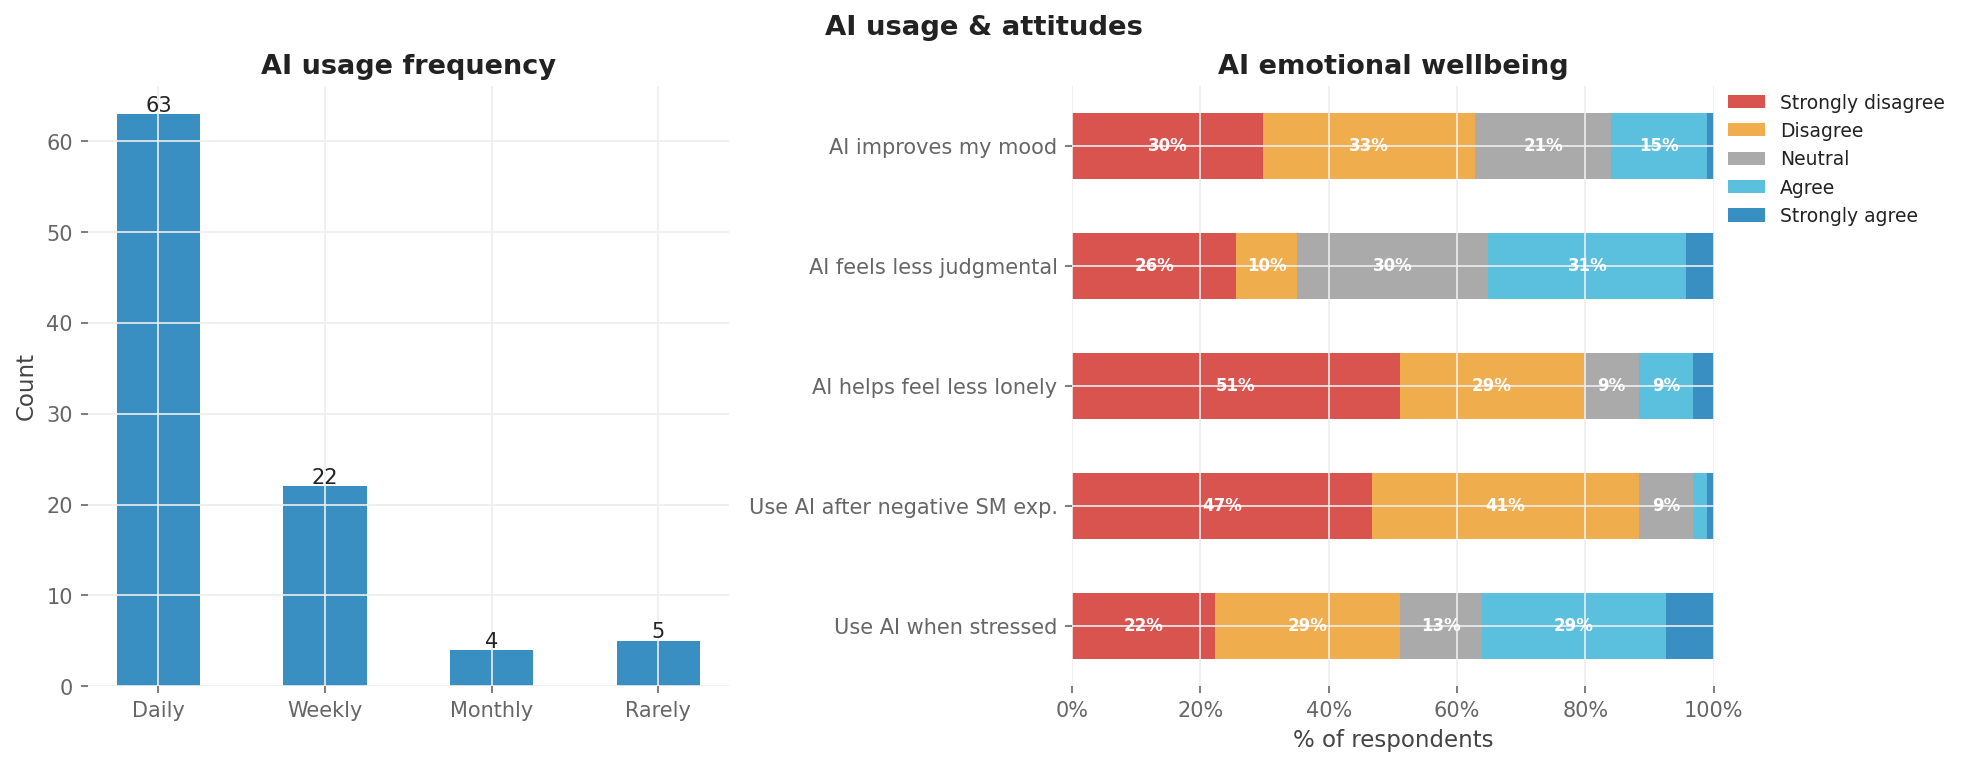

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle("AI usage & attitudes", fontweight="bold")

# Frequency
ai_order = ["Daily", "Weekly", "Monthly", "Rarely"]
ai_counts = df["ai_usage"].value_counts().reindex(ai_order).fillna(0)
axes[0].bar(ai_order, ai_counts.values, color="#3a8fc2", width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("AI usage frequency")
for i, v in enumerate(ai_counts.values):
    axes[0].text(i, v + 0.3, str(int(v)), ha="center", fontsize=10)

# Stacked Likert — AI mental health items
stacked_likert(axes[1], AI_LABELS, "AI emotional wellbeing")
axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),   # pushes legend outside the axes to the right
    borderaxespad=0,
    fontsize=9,
    ncol=1
)

plt.show()